In [114]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

import numpy as np
import matplotlib.pyplot as plt
from libertem_holo.base.generate import hologram_frame
import jax
from temgym_core.gaussian import square_input_wave, run_to_end_vmapped, InterpolatedSample2D, Detector, Biprism
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from interpax import Interpolator2D
from temgym_core.utils import energy2wavelength
jax.config.update("jax_enable_x64", True)

%matplotlib widget

In [115]:
voltage = 100e3  # in eV
wavelength = energy2wavelength(voltage)  # in meters
k = 2 * np.pi / wavelength  # in 1/meters
sx, sy = (256, 256)

Text(0.5, 1.0, 'Interpolated Image')

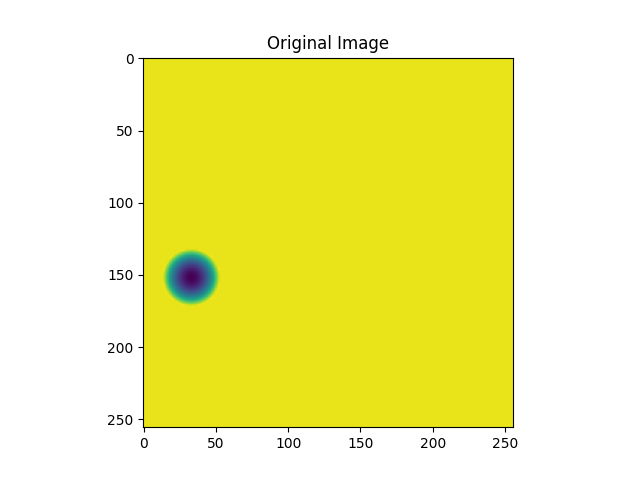

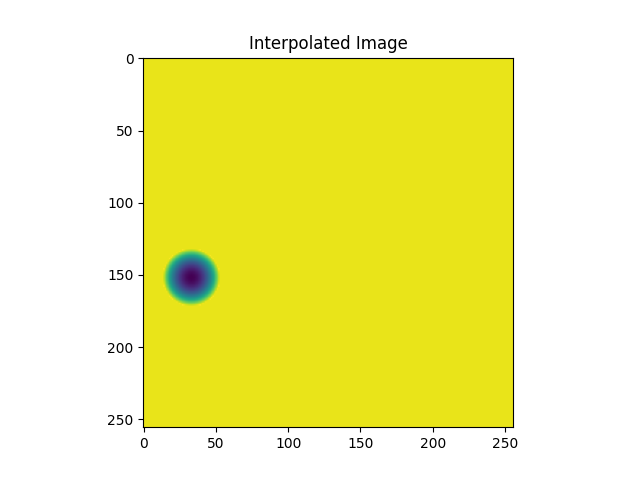

In [116]:
x = np.arange(sx)
y = np.arange(sy)
mx, my = np.meshgrid(x, y, indexing='ij')

x_pos, y_pos = 33., 103.

r2 = (mx - x_pos)**2 + (my - y_pos)**2
sphere = r2 < 20**2

opl = r2 / sx / 40.0
opl[sphere] += (-r2[sphere] / sx / 3.0 + 0.5) * 2.0
opl *= 1e-10

amp = np.ones_like(opl)
amp[sphere] = r2[sphere] / sx / 3.0 + 0.5

sample_cartesian = amp * np.exp(1j * opl)

interpolator = Interpolator2D(
    x=x,
    y=y,
    f=sample_cartesian,
    method='catmull-rom',
    extrap=0.0,
)

mx_q, my_q = np.meshgrid(x, y, indexing="ij")
interp_cartesian = interpolator(mx_q.ravel(), my_q.ravel()).reshape((sx, sy))

sample_image = np.flipud(sample_cartesian.T)
interp_image = np.flipud(interp_cartesian.T)

plt.figure()
plt.imshow(np.abs(sample_image), cmap='viridis')
plt.title("Original Image")

plt.figure()
plt.imshow(np.abs(interp_image), cmap='viridis')
plt.title("Interpolated Image")


Make the interpolated Sample for TemGym

In [117]:
detector = Detector(z=0.0, pixel_size=(1.0, 1.0), shape=(sy, sx), centre=(-sy//2, sx//2), flip_y=False)
sample_comp = InterpolatedSample2D.from_array(sample=sample_cartesian, x_coords=np.arange(sx), y_coords=np.arange(sy), z=0.0)

In [118]:
rays_in = square_input_wave(centre_xy=(sx//2, sy//2),
                            waist=0.25,
                            aperture_length=sx,
                            voltage=100e3,
                            overlap_factor=2.0)

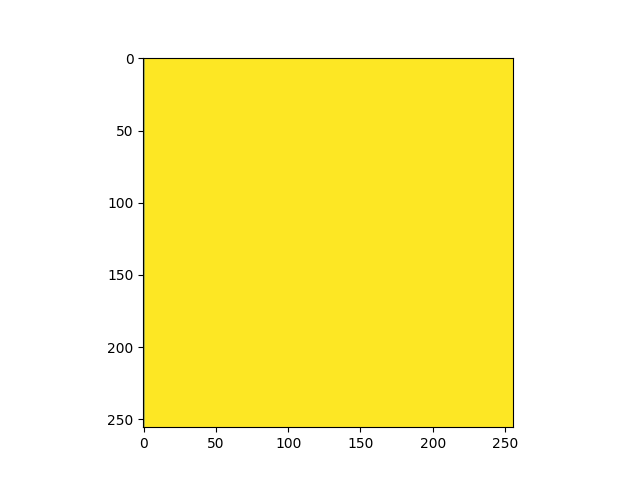

In [119]:
rays_in = run_to_end_vmapped(rays_in, (detector,))
field_out = evaluate_gaussians_gpu_kernel_wrapper(rays_in, detector).block_until_ready()


plt.figure()
plt.imshow(np.abs(field_out), cmap='viridis')

In [120]:
rays_out = run_to_end_vmapped(rays_in, (sample_comp,))
field_out = evaluate_gaussians_gpu_kernel_wrapper(rays_out, detector).block_until_ready()

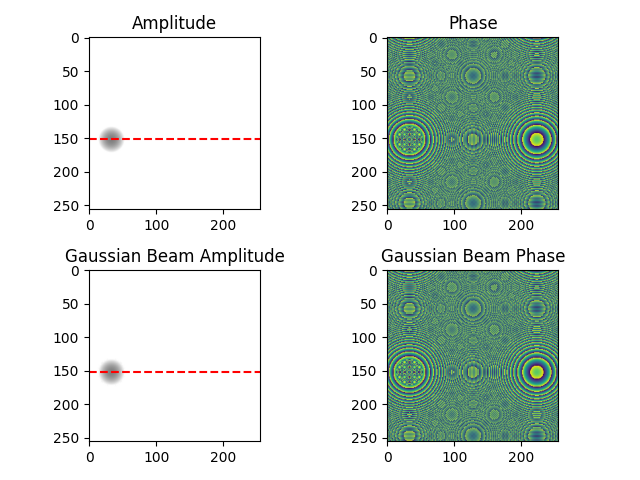

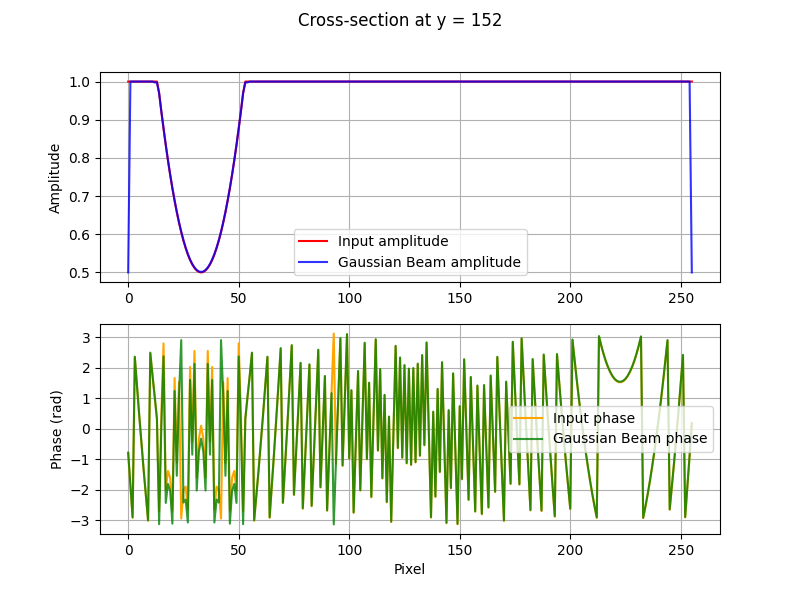

In [121]:
# Plot
sample_cartesian = amp * np.exp(1j * k * opl)
sample_image = np.flipud(sample_cartesian.T)

f, ax = plt.subplots(2, 2)
ax[0, 0].imshow(np.abs(sample_image), cmap='gray', vmax=1.0, vmin=0.0)
ax[0, 0].title.set_text('Amplitude')
ax[0, 1].imshow(np.angle(sample_image), cmap='viridis')
ax[0, 1].title.set_text('Phase')

ax[1, 0].imshow(np.abs(field_out), cmap='gray', vmax=1.0, vmin=0.0)
ax[1, 0].title.set_text('Gaussian Beam Amplitude')
ax[1, 1].imshow(np.angle(field_out), cmap='viridis')
ax[1, 1].title.set_text('Gaussian Beam Phase')

ax[0, 0].hlines(255 - 103, 0, 255, colors='r', linestyles='dashed')
ax[1, 0].hlines(255 - 103, 0, 255, colors='r', linestyles='dashed')

plt.tight_layout()

# Cross-section (amplitude + phase) along horizontal line at y = y_pos
y_idx = int(255 - y_pos)
x_pixels = np.arange(sx)

inp_amp = np.abs(sample_image)[y_idx, :]
out_amp = np.abs(np.asarray(field_out))[y_idx, :]

# phases (unwrap for nicer visualization)
inp_phase = np.angle(sample_image)[y_idx, :]
out_phase = np.angle(np.asarray(field_out))[y_idx, :]

plt.figure(figsize=(8, 6))
plt.suptitle(f'Cross-section at y = {y_idx}')

plt.subplot(2, 1, 1)
plt.plot(x_pixels, inp_amp, label='Input amplitude', color='red')
plt.plot(x_pixels, out_amp, label='Gaussian Beam amplitude', color='blue', alpha=0.8)
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x_pixels, inp_phase, label='Input phase', color='orange')
plt.plot(x_pixels, out_phase, label='Gaussian Beam phase', color='green', alpha=0.8)
plt.xlabel('Pixel')
plt.ylabel('Phase (rad)')
plt.legend()
plt.grid(True)



Use Libertem's analytic hologram function to calculate a hologram

In [122]:
sampling = 7.0  # in pixels

amp = np.abs(sample_image)
opl = np.angle(sample_image)
holo = hologram_frame(amp, opl / k, sampling=sampling, f_angle=90, counts=1)
ref = hologram_frame(np.ones_like(opl), np.zeros_like(opl), sampling=sampling, f_angle=90, counts=1)

Use temgym to also calculate a hologram from the same sample

In [123]:
# Calculate biprism strength needed for desired fringe spacing
# and it's image plane, where the friges will be observed.
z1 = 0.0
z2 = 10000000
biprism_z = 0.5
a = biprism_z - z1
b = ((z1 + z2) - biprism_z)
print(a, b)
b_def = wavelength * (a + b) / (2 * 7 * a)
print(b_def)

biprism = Biprism(z=a, strength=b_def, width = 1e-12, x0 = sx/2, y0 = -sy/2)
output_detector = Detector(z=a + b, pixel_size=(1.0, 1.0), shape=(sy, sx), centre=(-sy//2, sx//2), flip_y=False)
rays_out = run_to_end_vmapped(rays_in, (sample_comp, biprism, output_detector))

field_out = evaluate_gaussians_gpu_kernel_wrapper(rays_out, output_detector).block_until_ready()


0.5 9999999.5
5.2877665644662474e-06


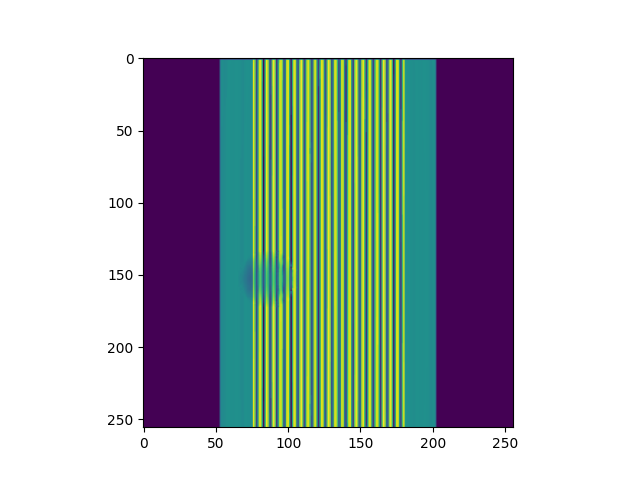

In [124]:
plt.figure()
plt.imshow(np.abs(field_out), cmap='viridis')
# plt.plot(rays_in.x, rays_in.y, 'r.')

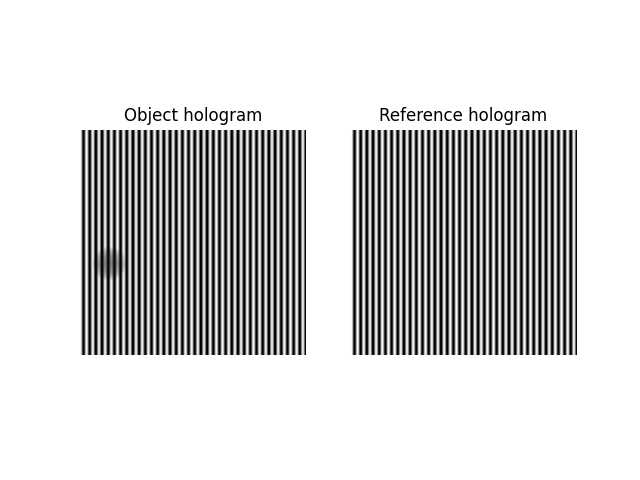

In [125]:


# Plot
f, ax = plt.subplots(1, 2)
ax[0].imshow(holo, cmap='gray')
ax[0].title.set_text('Object hologram')
ax[0].set_axis_off()
ax[1].imshow(ref, cmap='gray')
ax[1].title.set_text('Reference hologram')
ax[1].set_axis_off()